# Etapa 2. Entrenamiento seguro y evaluación

En este cuaderno se repite el proceso de entrenamiento con una separación clara entre los datos usados para ajustar el modelo y los reservados para la evaluación final. La búsqueda de parámetros se realiza solo en entrenamiento mediante validación cruzada. Después se evalúa el mejor candidato con una matriz de confusión, la curva ROC, el AUC y la exactitud.

## Separación de los datos

Se reserva el 20 % de los registros para la prueba final y se mantiene la proporción de las dos clases en ambos grupos. El preprocesamiento vive dentro del `Pipeline`; así, los valores de imputación, los niveles categóricos y las escalas no se calculan con los datos de prueba.

In [1]:
from pathlib import Path
import sys
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

ROOT = Path.cwd()
if not (ROOT / "data/raw/heart.csv").is_file():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.modeling import add_probability_calibration, compare_models, prepare_features_and_target, positive_class_scores

sns.set_theme(style="whitegrid", palette="deep")
df = pd.read_csv(ROOT / "data/raw/heart.csv")
X, y = prepare_features_and_target(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Entrenamiento: {len(X_train)} registros")
print(f"Prueba final: {len(X_test)} registros")
print("La respuesta conserva proporciones similares en ambos grupos:")
display(pd.DataFrame({
    "Entrenamiento": y_train.value_counts(normalize=True).sort_index(),
    "Prueba": y_test.value_counts(normalize=True).sort_index(),
}).rename_axis("HeartDisease").round(3))

Entrenamiento: 734 registros
Prueba final: 184 registros
La respuesta conserva proporciones similares en ambos grupos:


,Entrenamiento,Prueba
HeartDisease,,
0,0.447,0.446
1,0.553,0.554


## Búsqueda de modelos y selección

La búsqueda usa AUC como criterio de ajuste porque interesa que el modelo ordene adecuadamente los casos positivos y negativos. La exactitud se conserva como una medida complementaria. El primer lugar del ranking se define por el AUC promedio de validación cruzada, antes de consultar las métricas del conjunto de prueba.

In [2]:
resultados, busquedas = compare_models(
    X_train, y_train, X_test, y_test, n_splits=5, n_jobs=1
)
display(resultados[[
    "Posición", "Modelo", "AUC promedio CV", "AUC prueba", "Exactitud prueba"
]].round(3))

modelo_seleccionado_nombre = resultados.iloc[0]["Modelo"]
busqueda_seleccionada = busquedas[modelo_seleccionado_nombre]
modelo_seleccionado = busqueda_seleccionada.best_estimator_
print(f"Candidato seleccionado por validación cruzada: {modelo_seleccionado_nombre}")
print(f"Parámetros elegidos: {busqueda_seleccionada.best_params_}")

,Posición,Modelo,AUC promedio CV,AUC prueba,Exactitud prueba
0,1,Bosque aleatorio,0.933,0.937,0.886
1,2,Gradient Boosting,0.930,0.931,0.908
2,3,Regresión logística,0.928,0.932,0.891
3,4,SVC,0.925,0.944,0.880
4,5,K vecinos (KNN),0.920,0.947,0.897


Candidato seleccionado por validación cruzada: Bosque aleatorio
Parámetros elegidos: {'clasificador__max_depth': 5, 'clasificador__min_samples_leaf': 2, 'clasificador__n_estimators': 100}


## Evaluación en los datos reservados

La matriz de confusión muestra aciertos y errores por clase. La curva ROC resume cómo cambia la capacidad de separación al variar el punto de corte. Un AUC de 0,5 equivale aproximadamente a ordenar los casos al azar; un valor mayor indica una mejor separación en esta muestra.

AUC en prueba: 0.937
Exactitud en prueba: 0.886

Detalle por clase:


,precision,recall,f1-score,support
Sin enfermedad (0),0.918,0.817,0.865,82.000
Con enfermedad (1),0.865,0.941,0.901,102.000
accuracy,0.886,0.886,0.886,0.886
macro avg,0.891,0.879,0.883,184.000
weighted avg,0.888,0.886,0.885,184.000


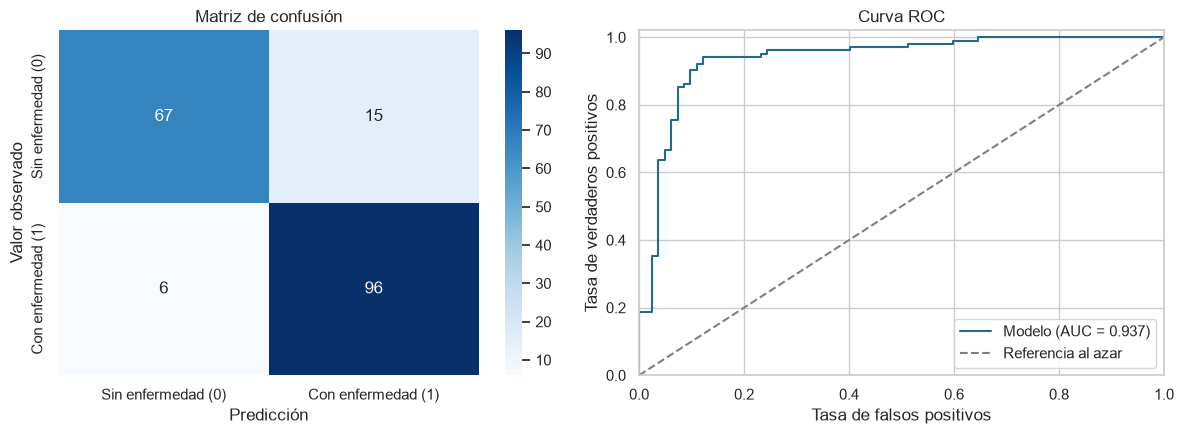

In [3]:
predicciones = modelo_seleccionado.predict(X_test)
puntajes = positive_class_scores(modelo_seleccionado, X_test)
auc_prueba = roc_auc_score(y_test, puntajes)
exactitud_prueba = accuracy_score(y_test, predicciones)
matriz = confusion_matrix(y_test, predicciones, labels=[0, 1])

print(f"AUC en prueba: {auc_prueba:.3f}")
print(f"Exactitud en prueba: {exactitud_prueba:.3f}")
print("\nDetalle por clase:")
display(pd.DataFrame(classification_report(
    y_test,
    predicciones,
    labels=[0, 1],
    target_names=["Sin enfermedad (0)", "Con enfermedad (1)"],
    output_dict=True,
    zero_division=0,
)).T.round(3))

fpr, tpr, _ = roc_curve(y_test, puntajes)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Sin enfermedad (0)", "Con enfermedad (1)"],
    yticklabels=["Sin enfermedad (0)", "Con enfermedad (1)"],
    ax=axes[0],
)
axes[0].set(title="Matriz de confusión", xlabel="Predicción", ylabel="Valor observado")
axes[1].plot(fpr, tpr, color="#246A8D", label=f"Modelo (AUC = {auc_prueba:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Referencia al azar")
axes[1].set(
    title="Curva ROC",
    xlabel="Tasa de falsos positivos",
    ylabel="Tasa de verdaderos positivos",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
axes[1].legend(loc="lower right")
plt.tight_layout()

In [4]:
fila_seleccionada = resultados.iloc[0]
brecha_cv = fila_seleccionada["AUC entrenamiento CV"] - fila_seleccionada["AUC promedio CV"]
print(
    f"El AUC de entrenamiento en validación cruzada fue "
    f"{fila_seleccionada['AUC entrenamiento CV']:.3f} y el promedio de validación "
    f"fue {fila_seleccionada['AUC promedio CV']:.3f}. La diferencia es {brecha_cv:.3f}."
)
print(
    "La diferencia ayuda a revisar si el ajuste en entrenamiento supera mucho "
    "el desempeño de validación. Se interpreta junto con la prueba reservada, "
    "no como una garantía de desempeño en otros pacientes o centros."
)

El AUC de entrenamiento en validación cruzada fue 0.967 y el promedio de validación fue 0.933. La diferencia es 0.033.
La diferencia ayuda a revisar si el ajuste en entrenamiento supera mucho el desempeño de validación. Se interpreta junto con la prueba reservada, no como una garantía de desempeño en otros pacientes o centros.


## Guardado del modelo

El modelo se guarda para conectarlo con la API de la siguiente etapa. Si el clasificador seleccionado no produce probabilidades de forma directa, se calibra usando únicamente los datos de entrenamiento. La verificación final confirma que el archivo puede abrirse y que entrega valores de probabilidad entre 0 y 1.

In [5]:
modelo_api = add_probability_calibration(modelo_seleccionado, X_train, y_train)
model_path = ROOT / "app" / "model.joblib"
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(modelo_api, model_path)

modelo_cargado = joblib.load(model_path)
probabilidades_muestra = modelo_cargado.predict_proba(X_test.iloc[:5])[:, 1]
assert len(probabilidades_muestra) == min(5, len(X_test))
assert ((probabilidades_muestra >= 0) & (probabilidades_muestra <= 1)).all()
print(f"Modelo guardado y verificado: {model_path.relative_to(ROOT)}")

Modelo guardado y verificado: app\model.joblib


## Lectura del resultado

La matriz permite ver qué tipos de error cometió el modelo en la prueba reservada. En este problema, un falso negativo significa que un registro con respuesta 1 se clasificó como 0; un falso positivo significa que un registro con respuesta 0 se clasificó como 1. Ambos errores deben revisarse con cuidado.

El resultado describe únicamente este conjunto y esta partición. No demuestra que el modelo pueda apoyar decisiones clínicas. En las siguientes etapas se revisará que el servicio reciba datos de forma consistente y que los cambios en datos nuevos puedan ser monitoreados.